# Fase 2: ejecucion larga del pipeline ergonomico

Esta libreta esta pensada para una corrida larga y reanudable del pipeline actual.

Objetivo:
- ejecutar `MediaPipe Pose` sobre un lote grande o el dataset completo
- guardar checkpoints incrementales para no perder trabajo
- dejar artefactos estables para revisar resultados sin repetir toda la corrida

Salidas esperadas por corrida:
- `execution_manifest.csv`
- `pose_landmarks.csv`
- `ergonomic_analysis.csv`
- `status_summary.csv`
- `group_status_summary.csv`
- `metric_summary_by_group.csv`



In [ ]:
from __future__ import annotations

import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    return current


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_columns = 60
pd.options.display.float_format = "{:,.3f}".format

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")



PROJECT_ROOT: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I
SRC_DIR: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/src


In [2]:
from ergonomics import (
    ERGONOMICS_RESULTS_DIR,
    MEDIAPIPE_TASK_MODEL_PATH,
    MediaPipePoseConfig,
    build_group_status_summary,
    build_metric_summary_by_group,
    build_status_summary,
    draw_pose_overlay,
    plot_metric_by_group,
    plot_status_by_group,
    plot_status_distribution,
    run_incremental_long_pipeline,
    select_execution_records,
)



## 1. Configuracion

Esta es la celda clave.
Para una corrida larga de verdad, deja `MAX_IMAGES = None`.
Si solo quieres probar, puedes limitarla con un entero pequeno o con la variable de entorno `ERGO_MAX_IMAGES`.



In [3]:
DATASET_KEY = "posture_correction_v4_folder_v1"
EXECUTION_STRATEGY = "full_dataset"
SPLITS = ("train", "valid", "test")
MAX_IMAGES = None
BALANCED_PER_GROUP = 300
SEED = 11

VISIBILITY_THRESHOLD = 0.35
CHECKPOINT_EVERY = 100
RESUME_RUN = True

DEFAULT_RUN_LABEL = f"{DATASET_KEY}_{EXECUTION_STRATEGY}"
RUN_LABEL = os.getenv("ERGO_RUN_LABEL", DEFAULT_RUN_LABEL)

if os.getenv("ERGO_MAX_IMAGES"):
    MAX_IMAGES = int(os.environ["ERGO_MAX_IMAGES"])

RUN_OUTPUT_DIR = ERGONOMICS_RESULTS_DIR / RUN_LABEL
RUN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

display(
    Markdown(
        f"""
**Configuracion activa**

- Dataset: `{DATASET_KEY}`
- Estrategia: `{EXECUTION_STRATEGY}`
- Splits: `{SPLITS}`
- Max images: `{MAX_IMAGES}`
- Balanced per group: `{BALANCED_PER_GROUP}`
- Threshold de visibilidad: `{VISIBILITY_THRESHOLD}`
- Checkpoint cada: `{CHECKPOINT_EVERY}` imagenes
- Resume: `{RESUME_RUN}`
- Carpeta de salida: `{RUN_OUTPUT_DIR}`
- Modelo MediaPipe: `{MEDIAPIPE_TASK_MODEL_PATH}`
"""
    )
)




**Configuracion activa**

- Dataset: `posture_correction_v4_folder_v1`
- Estrategia: `full_dataset`
- Splits: `('train', 'valid', 'test')`
- Max images: `None`
- Balanced per group: `300`
- Threshold de visibilidad: `0.35`
- Checkpoint cada: `100` imagenes
- Resume: `True`
- Carpeta de salida: `/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/notebooks/ergonomics/results/posture_correction_v4_folder_v1_full_dataset`
- Modelo MediaPipe: `/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/models/mediapipe/pose_landmarker_lite.task`


## 2. Manifest de ejecucion

Aqui se define la lista efectiva de imagenes a procesar.
En la estrategia `full_dataset`, esto normalmente significa todo el dataset base salvo que limites `MAX_IMAGES`.



In [4]:
records_df = select_execution_records(
    DATASET_KEY,
    strategy=EXECUTION_STRATEGY,
    per_group=BALANCED_PER_GROUP,
    max_images=MAX_IMAGES,
    splits=SPLITS,
    seed=SEED,
)

display(records_df.head(12))
display(records_df.groupby(["split", "group"]).size().rename("image_count").reset_index())
print(f"Total de imagenes programadas: {len(records_df)}")



,image_path,group,split
0,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,test
1,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,test
2,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,test
3,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,test
4,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,test
5,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,test
6,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,test
7,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,test
8,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,test
9,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,test


,split,group,image_count
0,test,looks good,105
1,test,sit up straight,386
2,test,straighten head,184
3,train,looks good,837
4,train,sit up straight,1663
5,train,straighten head,809
6,valid,looks good,163
7,valid,sit up straight,297
8,valid,straighten head,222


Total de imagenes programadas: 4666


## 3. Corrida larga y reanudable

Esta celda puede tardar.
Si la ejecucion se interrumpe, vuelve a lanzar la libreta con `RESUME_RUN = True`.
El pipeline detectara las imagenes ya procesadas y seguira desde ahi.



In [5]:
pose_config = MediaPipePoseConfig(
    model_path=MEDIAPIPE_TASK_MODEL_PATH,
    min_visibility=VISIBILITY_THRESHOLD,
)

run_started_at = datetime.now()
artifacts = run_incremental_long_pipeline(
    records_df,
    run_label=RUN_LABEL,
    pose_config=pose_config,
    visibility_threshold=VISIBILITY_THRESHOLD,
    checkpoint_every=CHECKPOINT_EVERY,
    resume=RESUME_RUN,
)
run_finished_at = datetime.now()

display(
    pd.DataFrame(
        [
            {"item": "Run label", "value": RUN_LABEL},
            {"item": "Output dir", "value": str(artifacts.output_dir)},
            {"item": "Processed images", "value": artifacts.processed_images},
            {"item": "Started at", "value": str(run_started_at)},
            {"item": "Finished at", "value": str(run_finished_at)},
            {"item": "Duration", "value": str(run_finished_at - run_started_at)},
        ]
    )
)



I0000 00:00:1776616426.626894   63381 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776616426.686577   63381 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776616428.843506   63381 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776616429.715896   63453 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:17

,item,value
0,Run label,posture_correction_v4_folder_v1_full_dataset
1,Output dir,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...
2,Processed images,4666
3,Started at,2026-04-19 18:33:45.919786
4,Finished at,2026-04-19 18:36:14.005598
5,Duration,0:02:28.085812


## 4. Cargar artefactos guardados

A partir de aqui todo sale de los CSV guardados en disco.
Eso permite revisar resultados sin rehacer la corrida completa.



In [6]:
manifest_df = pd.read_csv(artifacts.manifest_path)
pose_df = pd.read_csv(artifacts.pose_path)
analysis_df = pd.read_csv(artifacts.analysis_path)

status_summary_df = build_status_summary(analysis_df)
group_status_summary_df = build_group_status_summary(analysis_df)
metric_summary_df = build_metric_summary_by_group(
    analysis_df,
    metrics=[
        "shoulder_tilt_deg",
        "shoulder_height_diff_ratio",
        "head_lateral_offset_ratio",
        "neck_tilt_deg",
        "trunk_tilt_deg",
        "left_elbow_angle_deg",
        "right_elbow_angle_deg",
    ],
)

display(status_summary_df)
display(group_status_summary_df.head(12))
display(metric_summary_df)



,overall_status,image_count,share_pct
0,risk,2696,57.780
1,improvable,1181,25.311
2,adequate,782,16.760
3,insufficient_data,7,0.150


,group,overall_status,image_count,share_pct
0,looks good,adequate,249,22.534
1,looks good,improvable,394,35.656
2,looks good,risk,462,41.810
3,sit up straight,adequate,388,16.539
4,sit up straight,improvable,555,23.657
5,sit up straight,insufficient_data,7,0.298
6,sit up straight,risk,1396,59.506
7,straighten head,adequate,145,11.934
8,straighten head,improvable,232,19.095
9,straighten head,risk,838,68.971


,group,shoulder_tilt_deg,shoulder_height_diff_ratio,head_lateral_offset_ratio,neck_tilt_deg,trunk_tilt_deg,left_elbow_angle_deg,right_elbow_angle_deg
0,looks good,3.403,0.059,0.034,2.271,NaN,57.548,84.469
1,sit up straight,5.064,0.088,0.079,5.983,1.191,88.905,71.671
2,straighten head,5.943,0.103,0.134,7.444,0.589,33.780,52.719


## 5. Lectura rapida

Estas graficas son la primera capa de analisis para decidir si el pipeline esta listo para una fase mas estable
o si todavia hace falta refinar reglas y umbrales.



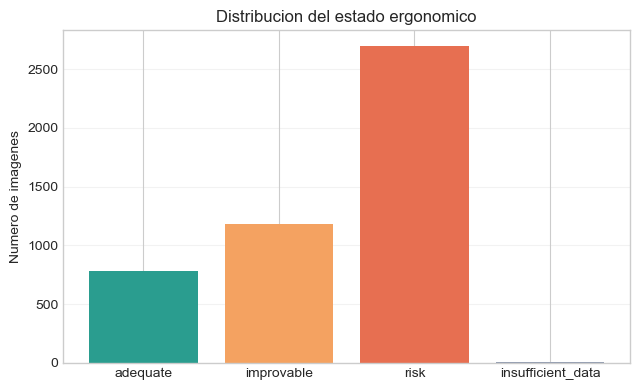

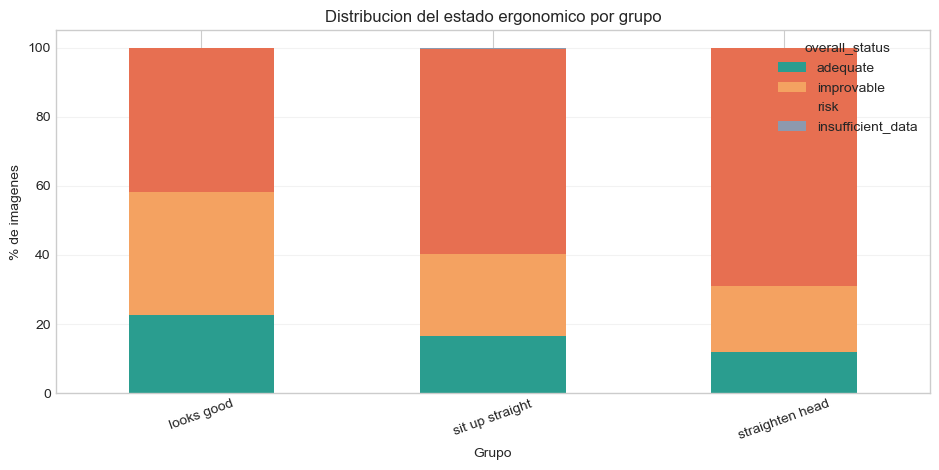

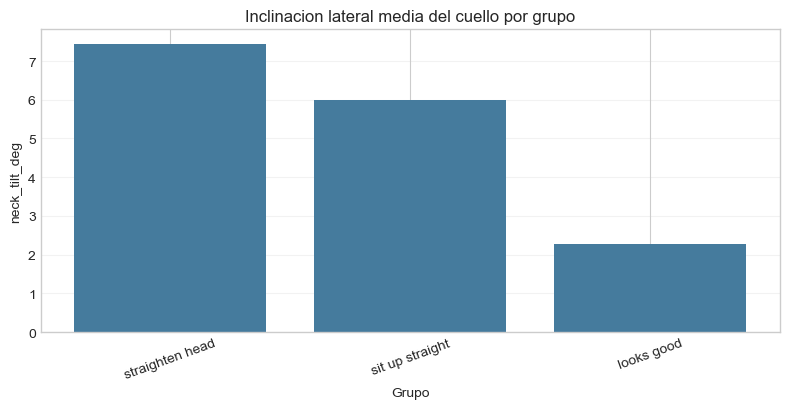

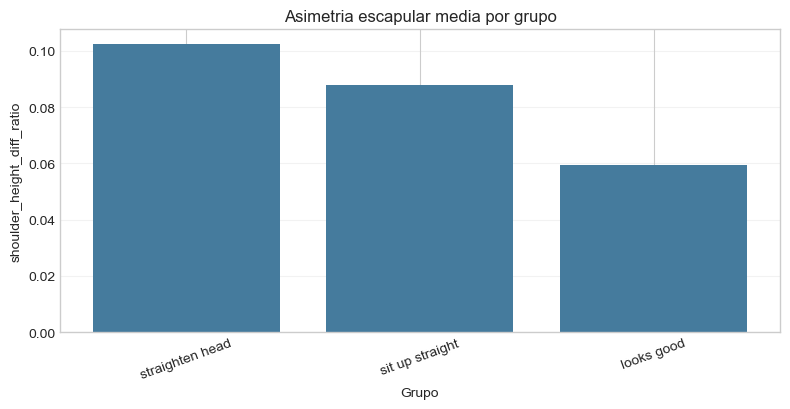

In [7]:
fig, ax = plot_status_distribution(analysis_df)
plt.show()

fig, ax = plot_status_by_group(analysis_df, normalize=True)
plt.show()

fig, ax = plot_metric_by_group(
    analysis_df,
    metric="neck_tilt_deg",
    title="Inclinacion lateral media del cuello por grupo",
)
plt.show()

fig, ax = plot_metric_by_group(
    analysis_df,
    metric="shoulder_height_diff_ratio",
    title="Asimetria escapular media por grupo",
)
plt.show()



## 6. Casos de ejemplo

Esta seccion ayuda a revisar ejemplos representativos sin abrir manualmente decenas o cientos de imagenes.



In [8]:
examples_df = (
    analysis_df.dropna(subset=["overall_status"])
    .sort_values(
        by=["overall_status", "group", "head_lateral_offset_ratio", "shoulder_height_diff_ratio"],
        ascending=[True, True, False, False],
    )
    .groupby("overall_status", as_index=False)
    .head(2)
    .reset_index(drop=True)
)

display(
    examples_df[
        [
            "image_name",
            "group",
            "overall_status",
            "shoulder_tilt_deg",
            "shoulder_height_diff_ratio",
            "head_lateral_offset_ratio",
            "neck_tilt_deg",
            "feedback",
        ]
    ]
)



,image_name,group,overall_status,shoulder_tilt_deg,shoulder_height_diff_ratio,head_lateral_offset_ratio,neck_tilt_deg,feedback
0,extract1123_jpg.rf.bb0c1dd98d233004a7d5d9cff17...,looks good,adequate,1.590,0.028,0.080,5.441,Sin alertas principales en esta primera revision.
1,extract1271_jpg.rf.271a92e4add1edf9a0212f0bf27...,looks good,adequate,1.607,0.028,0.079,5.350,Sin alertas principales en esta primera revision.
2,extract0246_jpg.rf.5916874b29feef3ced0001bef4b...,looks good,improvable,1.061,0.019,0.124,8.667,Recoloca la cabeza sobre el eje de los hombros...
3,extract0231_jpg.rf.4fb8f4603d68281db606257adad...,looks good,improvable,2.351,0.041,0.117,7.958,Recoloca la cabeza sobre el eje de los hombros...
4,extract1408_jpg.rf.d504e65418e99eaccfde3384b92...,sit up straight,insufficient_data,NaN,NaN,NaN,NaN,Sin alertas principales en esta primera revision.
5,extract1409_jpg.rf.ec31538e85c6f2d8ba068d08a0f...,sit up straight,insufficient_data,NaN,NaN,NaN,NaN,Sin alertas principales en esta primera revision.
6,extract0423_jpg.rf.6d7271fdec28f5bf352e7d6a5b2...,looks good,risk,3.860,0.067,0.209,12.516,Recoloca la cabeza sobre el eje de los hombros...
7,extract0436_jpg.rf.2544fba2226330c3676f23e62df...,looks good,risk,5.612,0.098,0.175,10.318,Recoloca la cabeza sobre el eje de los hombros...


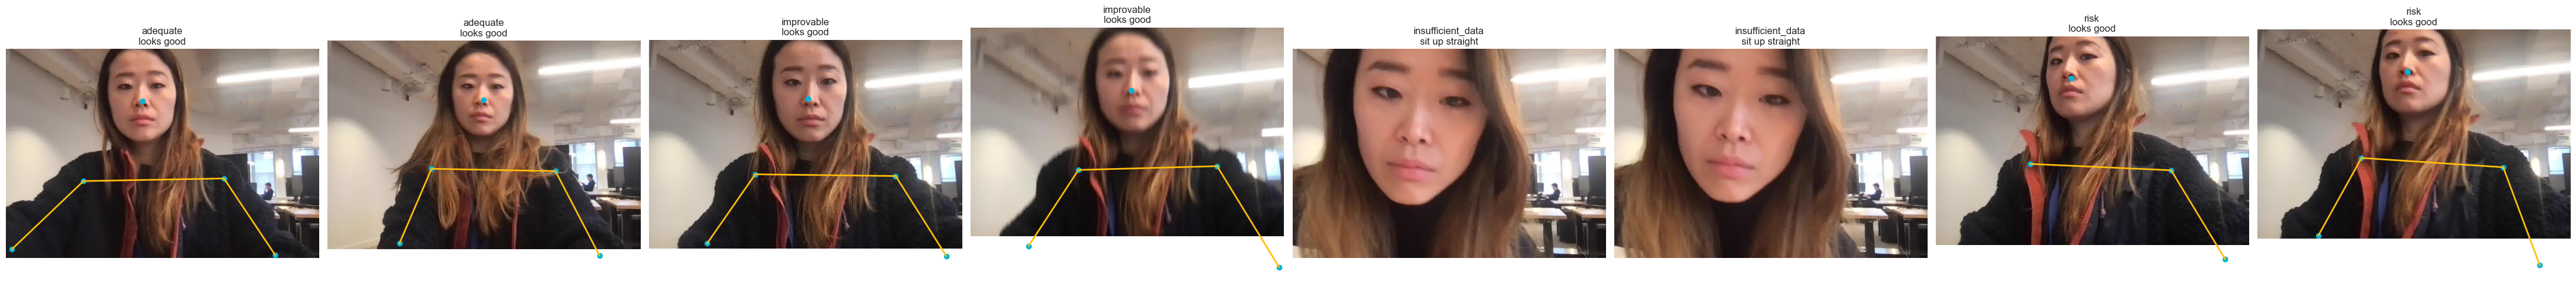

In [9]:
pose_lookup = pose_df.set_index("image_path")

fig, axes = plt.subplots(1, len(examples_df), figsize=(5.5 * len(examples_df), 5.5))
if len(examples_df) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, examples_df.iterrows(), strict=False):
    pose_row = pose_lookup.loc[row["image_path"]]
    draw_pose_overlay(row["image_path"], pose_row, ax=ax)
    ax.set_title(f"{row['overall_status']}\n{row['group']}")

plt.show()



## 7. Resumen final

Si esta corrida deja una salida razonable, el siguiente paso ya deberia ser valorar resultados y ajustar reglas,
no rehacer la infraestructura.



In [10]:
final_snapshot_df = pd.DataFrame(
    [
        {"item": "Run label", "value": RUN_LABEL},
        {"item": "Manifest images", "value": len(manifest_df)},
        {"item": "Pose rows", "value": len(pose_df)},
        {"item": "Analysis rows", "value": len(analysis_df)},
        {"item": "Adequate", "value": int((analysis_df["overall_status"] == "adequate").sum())},
        {"item": "Improvable", "value": int((analysis_df["overall_status"] == "improvable").sum())},
        {"item": "Risk", "value": int((analysis_df["overall_status"] == "risk").sum())},
        {"item": "Results dir", "value": str(artifacts.output_dir)},
    ]
)
display(final_snapshot_df)


,item,value
0,Run label,posture_correction_v4_folder_v1_full_dataset
1,Manifest images,4666
2,Pose rows,4666
3,Analysis rows,4666
4,Adequate,782
5,Improvable,1181
6,Risk,2696
7,Results dir,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...
